# Thai Vowel Classification — Grid Search (CNN+LSTM+Attention + Mel + CMVN)
Resumable grid search over CNN filters, LSTM units, dropout, learning rate, and batch size.

**Save-state pattern:** progress is checkpointed to Google Drive after every completed combination (`gs_savestate.json` + `gs_checkpoint.csv`), so the search can be stopped and resumed across Colab sessions without repeating finished combinations.

## Section 1 — Setup

In [ ]:
import os
import json
import time
import random
import itertools
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from pydub import AudioSegment
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Section 2 — Constants

In [ ]:
# ── Audio / Feature Constants ─────────────────────────────────────────────
SR          = 16000
HOP_LENGTH  = 512
N_FFT       = 2048
N_CLASSES   = 18
MAX_LEN     = 18          # p95 from duration analysis (matches ablation notebooks)
RANDOM_SEED = 42

VOWEL_LABELS = [
    'อา','อี','อือ','อู','เอ','แอ','โอ','ออ','เออ',
    'อะ','อิ','อึ','อุ','เอะ','แอะ','โอะ','เอาะ','เออะ'
]

# ── Grid Search Run Config ────────────────────────────────────────────────
N_FOLDS_GRID = 3          # 3-fold CV per combination (per user choice — ~40% faster than 5-fold)
GRID_EPOCHS  = 150        # capped epochs for search; EarlyStopping usually cuts this short
PATIENCE     = 15
BATCH_SIZE_DEFAULT = 32   # fallback; actual batch_size is swept in the grid

# ── Paths (Google Drive — survives Colab disconnects) ─────────────────────
BASE_PATH   = r'/content/drive/My Drive/dataset'
GS_DIR      = '/content/drive/MyDrive/gs_cnnlstm_mel_cmvn'
FEATURE_DIR = os.path.join(GS_DIR, 'features')          # cached X/y so we don't recompute across sessions
SAVESTATE_PATH  = os.path.join(GS_DIR, 'gs_savestate.json')
CHECKPOINT_PATH = os.path.join(GS_DIR, 'gs_checkpoint.csv')
BEST_CONFIG_PATH = os.path.join(GS_DIR, 'gs_best_config.json')

os.makedirs(GS_DIR, exist_ok=True)
os.makedirs(FEATURE_DIR, exist_ok=True)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f'Random seed fixed: {RANDOM_SEED}')
print(f'Grid search artifacts will be saved to: {GS_DIR}')

Random seed fixed: 42
Grid search artifacts will be saved to: /content/drive/MyDrive/gs_cnnlstm_mel_cmvn


## Section 3 — Load Dataset

In [ ]:
data = []
for label in os.listdir(BASE_PATH):
    folder = os.path.join(BASE_PATH, label)
    if os.path.isdir(folder):
        for file in os.listdir(folder):
            if file.endswith('.wav'):
                data.append([os.path.join(folder, file), label])

df = pd.DataFrame(data, columns=['file_path', 'label'])
print(f'Total samples : {len(df)}')
print(df['label'].value_counts())

Total samples : 1800
label
s4    100
s7    100
s8    100
s9    100
s2    100
s6    100
s5    100
s3    100
s1    100
09    100
08    100
06    100
07    100
03    100
05    100
04    100
02    100
01    100
Name: count, dtype: int64


## Section 4 — Preprocessing Functions (smart_crop)

In [ ]:
def detect_leading_silence(sound, silence_threshold=-30.0, chunk_size=10):
    trim_ms = 0
    while trim_ms < len(sound) and sound[trim_ms:trim_ms+chunk_size].dBFS < silence_threshold:
        trim_ms += chunk_size
    return trim_ms


def smart_crop(file_path, output_dir, window_ms=500, silence_threshold=-30.0):
    os.makedirs(output_dir, exist_ok=True)
    sound = AudioSegment.from_file(file_path)

    start = detect_leading_silence(sound, silence_threshold)
    end   = detect_leading_silence(sound.reverse(), silence_threshold)
    trimmed = sound[start : len(sound) - end]

    if len(trimmed) == 0:
        trimmed = sound

    chunk_ms  = 10
    energies  = [trimmed[i:i+chunk_ms].rms for i in range(0, len(trimmed), chunk_ms)]
    peak_idx  = int(np.argmax(energies))
    peak_ms   = peak_idx * chunk_ms

    half       = window_ms // 2
    crop_start = max(0, peak_ms - half)
    crop_end   = min(len(trimmed), crop_start + window_ms)
    final      = trimmed[crop_start:crop_end]

    out_path = os.path.join(output_dir, f'sc_{os.path.basename(file_path)}')
    final.export(out_path, format='wav')
    return out_path

## Section 5 — Feature Extraction (Log-Mel Spectrogram + CMVN)

In [ ]:
def extract_mel(file_path, max_len=18):
    wave, _ = librosa.load(file_path, mono=True, sr=SR)
    mel    = librosa.feature.melspectrogram(y=wave, sr=SR,
                                             n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    if mel_db.shape[1] < max_len:
        mel_db = np.pad(mel_db, ((0,0),(0, max_len - mel_db.shape[1])), mode='constant')
    else:
        mel_db = mel_db[:, :max_len]

    # Step 1: Global norm (เหมือนเดิม — เก็บ energy contour ไว้)
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)

    # Step 2: CMVN เบาๆ ด้วย alpha=0.5 (ลด speaker bias แต่ไม่ลบ energy ทิ้ง)
    alpha  = 0.5
    mean   = mel_db.mean(axis=1, keepdims=True)
    std    = mel_db.std(axis=1,  keepdims=True) + 1e-6
    mel_db = mel_db - alpha * mean   # shift mean เท่านั้น ไม่หาร std

    return mel_db

## Section 6 — Data Augmentation

In [ ]:
def augment_mel(mel_db):
    augmented = []

    # ── Time shift: roll along time axis ──────────────────────────────────
    shift = np.random.randint(1, max(2, mel_db.shape[1] // 4))
    augmented.append(np.roll(mel_db, shift, axis=1))

    # ── Frequency masking (SpecAugment-lite) ──────────────────────────────
    mel_fm = mel_db.copy()
    f0 = np.random.randint(0, mel_db.shape[0] // 4)
    f_width = np.random.randint(4, 12)
    mel_fm[f0:f0+f_width, :] = mel_db.mean()
    augmented.append(mel_fm)

    # ── Time masking (SpecAugment-lite) ───────────────────────────────────
    mel_tm = mel_db.copy()
    t0 = np.random.randint(0, max(1, mel_db.shape[1] - 4))
    t_width = np.random.randint(1, max(2, mel_db.shape[1] // 6))
    mel_tm[:, t0:t0+t_width] = mel_db.mean()
    augmented.append(mel_tm)

    # ── Gaussian noise ─────────────────────────────────────────────────────
    noise = np.random.normal(0, 0.05, mel_db.shape)
    augmented.append(mel_db + noise)

    return augmented  # 4 variants per sample


def build_augmented_dataset(X, y, seed=42):
    np.random.seed(seed)
    X_aug, y_aug = [X], [y]
    for variant in range(4):
        X_new = np.array([augment_mel(x)[variant] for x in X])
        X_aug.append(X_new)
        y_aug.append(y)
    X_aug = np.concatenate(X_aug, axis=0)
    y_aug = np.concatenate(y_aug, axis=0)

    idx = np.random.permutation(len(X_aug))
    return X_aug[idx], y_aug[idx]

print('Augmentation functions ready.')

Augmentation functions ready.


## Section 7 — Build Full Dataset (cached to Drive)
Feature extraction runs once; on re-run (e.g. after a Colab disconnect) it loads the cached `.npy` files instead of recomputing.

In [ ]:
X_CACHE = os.path.join(FEATURE_DIR, f'X_maxlen{MAX_LEN}.npy')
Y_CACHE = os.path.join(FEATURE_DIR, f'y_maxlen{MAX_LEN}.npy')
LE_CACHE = os.path.join(FEATURE_DIR, 'label_encoder_classes.npy')

if os.path.exists(X_CACHE) and os.path.exists(Y_CACHE):
    print('Loading cached features from Drive...')
    X = np.load(X_CACHE)
    y_int = np.load(Y_CACHE)
    le_classes = np.load(LE_CACHE, allow_pickle=True)
    le = LabelEncoder()
    le.classes_ = le_classes
else:
    print('No cache found — extracting features (this runs once)...')
    PROC_DIR = '/content/proc_smartcrop'

    processed_paths = [
        smart_crop(fp, PROC_DIR)
        for fp in tqdm(df['file_path'], desc='smart_crop')
    ]

    X = np.array([
        extract_mel(p, max_len=MAX_LEN)
        for p in tqdm(processed_paths, desc='Mel extraction')
    ])

    le = LabelEncoder()
    y_int = le.fit_transform(df['label'])

    np.save(X_CACHE, X)
    np.save(Y_CACHE, y_int)
    np.save(LE_CACHE, le.classes_)
    print('Features cached to Drive.')

print(f'X shape : {X.shape}')
print(f'Classes : {le.classes_}')

Loading cached features from Drive...
X shape : (1797, 128, 18)
Classes : ['01' '02' '03' '04' '05' '06' '07' '08' '09' 's1' 's2' 's3' 's4' 's5'
 's6' 's7' 's8' 's9']


## Section 8 — Hold-Out Test Split (10%, excluded from grid search)

In [ ]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_int,
    test_size=0.10,
    random_state=RANDOM_SEED,
    stratify=y_int
)

print(f'Train+Val (used for grid search CV) : {X_trainval.shape[0]} samples')
print(f'Test (held out, NOT used in search)  : {X_test.shape[0]} samples')

Train+Val (used for grid search CV) : 1617 samples
Test (held out, NOT used in search)  : 180 samples


## Section 9 — Model Architecture (parameterized for grid search)

In [ ]:
@tf.keras.utils.register_keras_serializable()
class BahdanauAttention(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.W = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, lstm_output):
        score   = self.V(tf.nn.tanh(self.W(lstm_output)))
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(weights * lstm_output, axis=1)
        return context, weights

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units})
        return config

In [ ]:
def build_model(input_shape, cnn_filters=(32, 64), lstm_units=512,
                 dropout=0.25, learning_rate=1e-3):
    """Parameterized version of the CNN+LSTM+Attention architecture.

    cnn_filters : tuple(int, int) — filters for the two Conv2D blocks
    lstm_units  : int             — units per LSTM layer (both layers use the same value)
    dropout     : float           — applied after each CNN block and after the LSTM stack
                                     (LSTM internal recurrent dropout uses dropout + 0.1, capped at 0.5)
    learning_rate : float         — Adam learning rate
    """
    f1, f2 = cnn_filters
    lstm_dropout = min(dropout + 0.10, 0.5)

    inp = layers.Input(shape=input_shape)

    # ── CNN block ──
    x = layers.Conv2D(f1, (3, 3), activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 1))(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Conv2D(f2, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 1))(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Permute((2, 1, 3))(x)
    shape = x.shape
    x = layers.Reshape((shape[1], shape[2] * shape[3]))(x)

    # ── LSTM block ──
    x = layers.LSTM(lstm_units, activation='tanh', return_sequences=True, dropout=lstm_dropout)(x)
    x = layers.LSTM(lstm_units, activation='tanh', return_sequences=True, dropout=lstm_dropout)(x)
    x = layers.Dropout(lstm_dropout)(x)

    context, attn_weights = BahdanauAttention(lstm_units)(x)

    out = layers.Dense(N_CLASSES, activation='softmax')(context)

    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Quick sanity check with default hyperparameters
_dummy = build_model((X_trainval.shape[1], X_trainval.shape[2], 1))
print(f'Model builds OK — {_dummy.count_params():,} params (default config)')

Model builds OK — 7,635,731 params (default config)


## Section 10 — Grid Definition
Sweeping **CNN filters, LSTM units, dropout, learning rate, and batch size** — 2 values each (2⁵ = 32 combinations). Each combination gets a stable string key used for save-state tracking.

In [ ]:
PARAM_GRID = {
    'cnn_filters':   [(32, 64), (64, 128)],
    'lstm_units':    [256, 512],
    'dropout':       [0.25, 0.30,0.35,0.40],
    'learning_rate': [1e-3, 5e-4],
    'batch_size':    [32, 64],
}

def make_combos(grid):
    keys = list(grid.keys())
    combos = []
    for values in itertools.product(*[grid[k] for k in keys]):
        combos.append(dict(zip(keys, values)))
    return combos

def combo_key(combo):
    # stable, filesystem/CSV-safe identifier for a hyperparameter combination
    parts = []
    for k in sorted(combo.keys()):
        v = combo[k]
        v_str = f'{v[0]}-{v[1]}' if isinstance(v, tuple) else str(v)
        parts.append(f'{k}={v_str}')
    return '|'.join(parts)

ALL_COMBOS = make_combos(PARAM_GRID)
print(f'Total combinations: {len(ALL_COMBOS)}')
print(f'Total trainings (combos × {N_FOLDS_GRID}-fold CV): {len(ALL_COMBOS) * N_FOLDS_GRID}')
print('\nExample combo key:')
print(' ', combo_key(ALL_COMBOS[0]))

Total combinations: 64
Total trainings (combos × 3-fold CV): 192

Example combo key:
  batch_size=32|cnn_filters=32-64|dropout=0.25|learning_rate=0.001|lstm_units=256


## Section 11 — Save-State Helpers (resume support)

In [ ]:
def load_savestate():
    if os.path.exists(SAVESTATE_PATH):
        with open(SAVESTATE_PATH, 'r', encoding='utf-8') as f:
            return json.load(f)
    return {'completed_keys': [], 'last_updated': None}


def save_savestate(state):
    state['last_updated'] = time.strftime('%Y-%m-%d %H:%M:%S')
    with open(SAVESTATE_PATH, 'w', encoding='utf-8') as f:
        json.dump(state, f, ensure_ascii=False, indent=2)


def append_checkpoint_row(row: dict):
    """Append one completed combination's results to the checkpoint CSV."""
    df_row = pd.DataFrame([row])
    if os.path.exists(CHECKPOINT_PATH):
        df_row.to_csv(CHECKPOINT_PATH, mode='a', header=False, index=False)
    else:
        df_row.to_csv(CHECKPOINT_PATH, mode='w', header=True, index=False)


state = load_savestate()
print(f"Combinations already completed: {len(state['completed_keys'])} / {len(ALL_COMBOS)}")
if state['last_updated']:
    print(f"Last updated: {state['last_updated']}")

Combinations already completed: 64 / 64
Last updated: 2026-07-31 03:57:31


## Section 12 — Grid Search Execution (resumable)
Runs 3-fold CV per combination. Already-completed combinations (per `gs_savestate.json`) are skipped, so re-running this cell after a disconnect picks up where it left off.

In [ ]:
def run_cv_for_combo(combo, X_trainval, y_trainval, n_folds=N_FOLDS_GRID):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_SEED)
    X_tv = X_trainval[..., np.newaxis]

    fold_scores = []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
        random.seed(RANDOM_SEED * fold)
        np.random.seed(RANDOM_SEED * fold)
        tf.random.set_seed(RANDOM_SEED * fold)

        X_tr, X_val = X_tv[tr_idx], X_tv[val_idx]
        y_tr, y_val = y_trainval[tr_idx], y_trainval[val_idx]

        # augment training fold only
        X_tr_sq = X_tr.squeeze(-1)
        X_tr_aug, y_tr_aug = build_augmented_dataset(X_tr_sq, y_tr, seed=RANDOM_SEED * fold)
        X_tr_aug = X_tr_aug[..., np.newaxis]

        y_tr_cat  = to_categorical(y_tr_aug, N_CLASSES)
        y_val_cat = to_categorical(y_val, N_CLASSES)

        model = build_model(
            X_tr_aug.shape[1:],
            cnn_filters=combo['cnn_filters'],
            lstm_units=combo['lstm_units'],
            dropout=combo['dropout'],
            learning_rate=combo['learning_rate'],
        )

        callbacks = [
            EarlyStopping(monitor='val_loss', patience=PATIENCE,
                          restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=max(4, PATIENCE // 2), min_lr=1e-6, verbose=0),
        ]

        model.fit(
            X_tr_aug, y_tr_cat,
            epochs=GRID_EPOCHS, batch_size=combo['batch_size'],
            validation_data=(X_val, y_val_cat),
            callbacks=callbacks, verbose=0
        )

        val_loss, val_acc = model.evaluate(X_val, y_val_cat, verbose=0)
        y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
        f1 = f1_score(y_val, y_pred, average='macro')

        fold_scores.append({'val_acc': val_acc, 'val_f1_macro': f1, 'val_loss': val_loss})

        tf.keras.backend.clear_session()

    return fold_scores


print(f'Starting grid search: {len(ALL_COMBOS)} combinations, {N_FOLDS_GRID}-fold CV each')
print('=' * 70)

for i, combo in enumerate(ALL_COMBOS, 1):
    key = combo_key(combo)

    if key in state['completed_keys']:
        print(f'[{i}/{len(ALL_COMBOS)}] SKIP (already done): {key}')
        continue

    print(f'[{i}/{len(ALL_COMBOS)}] Running: {key}')
    t0 = time.time()

    try:
        fold_scores = run_cv_for_combo(combo, X_trainval, y_trainval)
        elapsed = time.time() - t0

        accs = [s['val_acc'] for s in fold_scores]
        f1s  = [s['val_f1_macro'] for s in fold_scores]
        losses = [s['val_loss'] for s in fold_scores]

        row = {
            'combo_key': key,
            'cnn_filters': f"{combo['cnn_filters'][0]}-{combo['cnn_filters'][1]}",
            'lstm_units': combo['lstm_units'],
            'dropout': combo['dropout'],
            'learning_rate': combo['learning_rate'],
            'batch_size': combo['batch_size'],
            'val_acc_mean': np.mean(accs),
            'val_acc_std': np.std(accs),
            'val_f1_macro_mean': np.mean(f1s),
            'val_f1_macro_std': np.std(f1s),
            'val_loss_mean': np.mean(losses),
            'n_folds': N_FOLDS_GRID,
            'elapsed_sec': round(elapsed, 1),
            'status': 'ok',
        }
        append_checkpoint_row(row)

        state['completed_keys'].append(key)
        save_savestate(state)

        print(f"  -> Val Acc: {row['val_acc_mean']*100:.2f}% | "
              f"Macro F1: {row['val_f1_macro_mean']:.4f} | "
              f"{elapsed:.0f}s")

    except Exception as e:
        elapsed = time.time() - t0
        print(f'  -> ERROR after {elapsed:.0f}s: {e}')
        row = {
            'combo_key': key,
            'cnn_filters': f"{combo['cnn_filters'][0]}-{combo['cnn_filters'][1]}",
            'lstm_units': combo['lstm_units'],
            'dropout': combo['dropout'],
            'learning_rate': combo['learning_rate'],
            'batch_size': combo['batch_size'],
            'val_acc_mean': None, 'val_acc_std': None,
            'val_f1_macro_mean': None, 'val_f1_macro_std': None,
            'val_loss_mean': None,
            'n_folds': N_FOLDS_GRID,
            'elapsed_sec': round(elapsed, 1),
            'status': f'error: {e}',
        }
        append_checkpoint_row(row)
        # NOTE: failed combos are logged but NOT marked completed, so they'll retry on re-run.
        continue

print('=' * 70)
print('Grid search pass complete.')
print(f"Total completed: {len(state['completed_keys'])} / {len(ALL_COMBOS)}")
if len(state['completed_keys']) < len(ALL_COMBOS):
    print('Re-run this cell to continue with remaining/failed combinations.')

Starting grid search: 64 combinations, 3-fold CV each
[1/64] SKIP (already done): batch_size=32|cnn_filters=32-64|dropout=0.25|learning_rate=0.001|lstm_units=256
[2/64] SKIP (already done): batch_size=64|cnn_filters=32-64|dropout=0.25|learning_rate=0.001|lstm_units=256
[3/64] SKIP (already done): batch_size=32|cnn_filters=32-64|dropout=0.25|learning_rate=0.0005|lstm_units=256
[4/64] SKIP (already done): batch_size=64|cnn_filters=32-64|dropout=0.25|learning_rate=0.0005|lstm_units=256
[5/64] SKIP (already done): batch_size=32|cnn_filters=32-64|dropout=0.3|learning_rate=0.001|lstm_units=256
[6/64] SKIP (already done): batch_size=64|cnn_filters=32-64|dropout=0.3|learning_rate=0.001|lstm_units=256
[7/64] SKIP (already done): batch_size=32|cnn_filters=32-64|dropout=0.3|learning_rate=0.0005|lstm_units=256
[8/64] SKIP (already done): batch_size=64|cnn_filters=32-64|dropout=0.3|learning_rate=0.0005|lstm_units=256
[9/64] SKIP (already done): batch_size=32|cnn_filters=32-64|dropout=0.35|learning_

## Section 13 — Results Analysis

In [ ]:
results = pd.read_csv(CHECKPOINT_PATH)
results_ok = results[results['status'] == 'ok'].copy()

print(f'Total logged rows   : {len(results)}')
print(f'Successful combos   : {len(results_ok)}')
print(f'Failed combos       : {len(results) - len(results_ok)}')

results_ok_sorted = results_ok.sort_values('val_f1_macro_mean', ascending=False)
print('\nTop 10 combinations by Macro F1:')
results_ok_sorted[[
    'cnn_filters', 'lstm_units', 'dropout', 'learning_rate', 'batch_size',
    'val_acc_mean', 'val_f1_macro_mean', 'val_f1_macro_std', 'elapsed_sec'
]].head(10)

Total logged rows   : 64
Successful combos   : 64
Failed combos       : 0

Top 10 combinations by Macro F1:


,cnn_filters,lstm_units,dropout,learning_rate,batch_size,val_acc_mean,val_f1_macro_mean,val_f1_macro_std,elapsed_sec
50,64-128,256,0.30,0.0005,32,0.958565,0.958602,0.009660,899.9
48,64-128,256,0.30,0.0010,32,0.957947,0.957994,0.009826,798.4
51,64-128,256,0.30,0.0005,64,0.956092,0.956391,0.008106,653.8
18,64-128,256,0.25,0.0005,32,0.955473,0.955571,0.006412,792.5
36,32-64,256,0.35,0.0010,32,0.953618,0.953910,0.007674,561.8
53,64-128,256,0.35,0.0010,64,0.953618,0.953797,0.013683,610.5
59,64-128,512,0.30,0.0005,64,0.953618,0.953698,0.011444,805.2
16,64-128,256,0.25,0.0010,32,0.952999,0.953347,0.008909,704.4
58,64-128,512,0.30,0.0005,32,0.952999,0.953220,0.009863,983.7
22,64-128,256,0.40,0.0005,32,0.952381,0.952648,0.006055,797.6


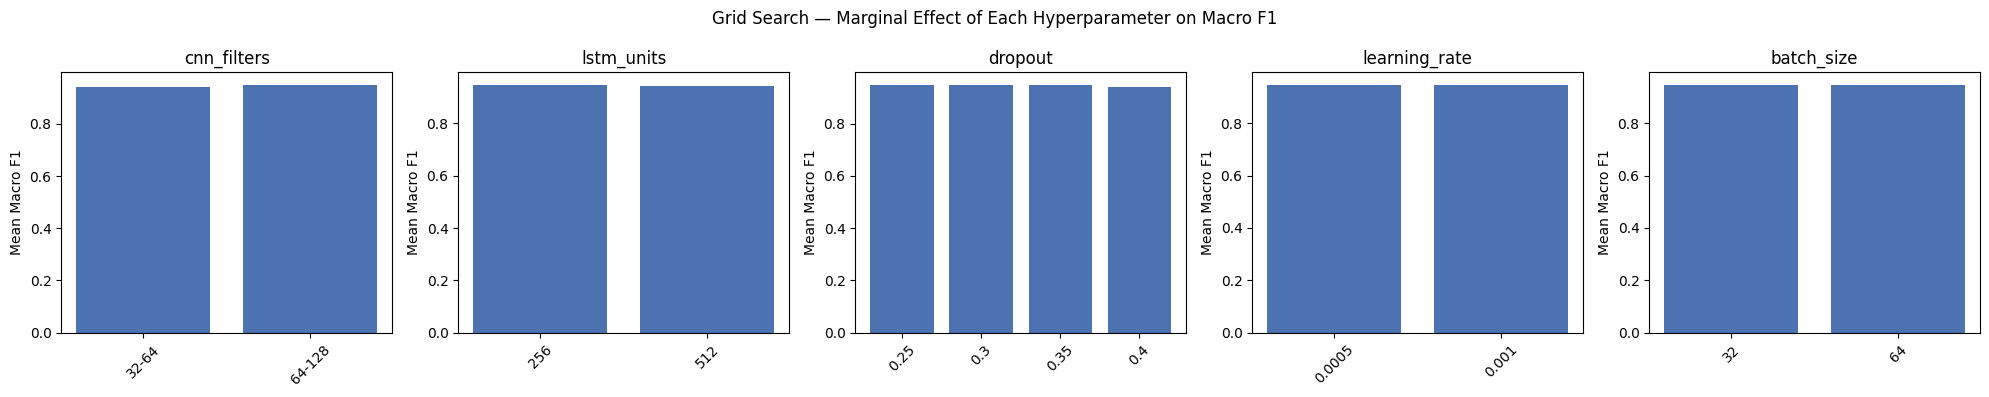

In [ ]:
import matplotlib.pyplot as plt

# ── Per-hyperparameter effect on Macro F1 (marginal means) ─────────────────
param_cols = ['cnn_filters', 'lstm_units', 'dropout', 'learning_rate', 'batch_size']

fig, axes = plt.subplots(1, len(param_cols), figsize=(20, 4))
for ax, col in zip(axes, param_cols):
    grouped = results_ok.groupby(col)['val_f1_macro_mean'].mean().sort_index()
    ax.bar(grouped.index.astype(str), grouped.values, color='#4C72B0')
    ax.set_title(col)
    ax.set_ylabel('Mean Macro F1')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Grid Search — Marginal Effect of Each Hyperparameter on Macro F1')
plt.tight_layout()
plt.savefig(os.path.join(GS_DIR, 'gs_marginal_effects.png'), dpi=150)
plt.show()

## Section 14 — Save Best Configuration

In [ ]:
best_row = results_ok_sorted.iloc[0]

best_config = {
    'cnn_filters': [int(x) for x in best_row['cnn_filters'].split('-')],
    'lstm_units': int(best_row['lstm_units']),
    'dropout': float(best_row['dropout']),
    'learning_rate': float(best_row['learning_rate']),
    'batch_size': int(best_row['batch_size']),
    'cv_val_acc_mean': float(best_row['val_acc_mean']),
    'cv_val_f1_macro_mean': float(best_row['val_f1_macro_mean']),
    'n_folds_used': int(best_row['n_folds']),
    'selected_at': time.strftime('%Y-%m-%d %H:%M:%S'),
}

with open(BEST_CONFIG_PATH, 'w', encoding='utf-8') as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)

print('Best configuration:')
print(json.dumps(best_config, ensure_ascii=False, indent=2))
print(f'\nSaved to: {BEST_CONFIG_PATH}')
print('\nUse these hyperparameters in the final CNN+LSTM+Attention training notebook')
print('(re-run with N_FOLDS=5 and full EPOCHS/patience for the reported result).')

Best configuration:
{
  "cnn_filters": [
    64,
    128
  ],
  "lstm_units": 256,
  "dropout": 0.3,
  "learning_rate": 0.0005,
  "batch_size": 32,
  "cv_val_acc_mean": 0.9585652550061544,
  "cv_val_f1_macro_mean": 0.9586016646709729,
  "n_folds_used": 3,
  "selected_at": "2026-07-31 05:44:23"
}

Saved to: /content/drive/MyDrive/gs_cnnlstm_mel_cmvn/gs_best_config.json

Use these hyperparameters in the final CNN+LSTM+Attention training notebook
(re-run with N_FOLDS=5 and full EPOCHS/patience for the reported result).
